In [6]:
import pandas as pd

df = pd.read_csv("../data/Reviews.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 43.4 MB


In [8]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [9]:
df['Score'].value_counts().sort_index()

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

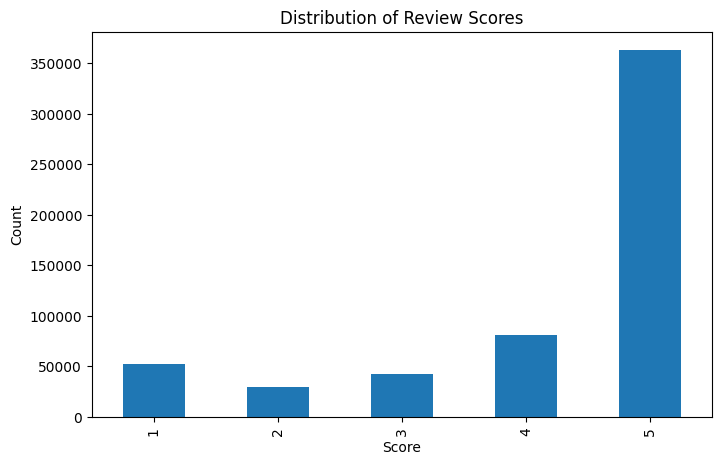

In [10]:
import matplotlib.pyplot as plt

df['Score'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

In [11]:
df_sentiment = df[df['Score'] != 3].copy()

df_sentiment['Sentiment'] = df_sentiment['Score'].apply(
    lambda x: 1 if x >= 4 else 0
)

print(df_sentiment.shape)

df_sentiment['Sentiment'].value_counts()

(525814, 11)


Sentiment
1    443777
0     82037
Name: count, dtype: int64

In [12]:
df_model = df_sentiment[['Text', 'Sentiment']].copy()

print(df_model.shape)

df_model.head()

(525814, 2)


,Text,Sentiment
0,I have bought several of the Vitality canned d...,1
1,Product arrived labeled as Jumbo Salted Peanut...,0
2,This is a confection that has been around a fe...,1
3,If you are looking for the secret ingredient i...,0
4,Great taffy at a great price. There was a wid...,1


In [13]:
df_model['review_length'] = df_model['Text'].apply(len)

df_model['review_length'].describe()

count    525814.000000
mean        429.402317
std         439.170342
min          12.000000
25%         177.000000
50%         296.000000
75%         517.000000
max       16952.000000
Name: review_length, dtype: float64

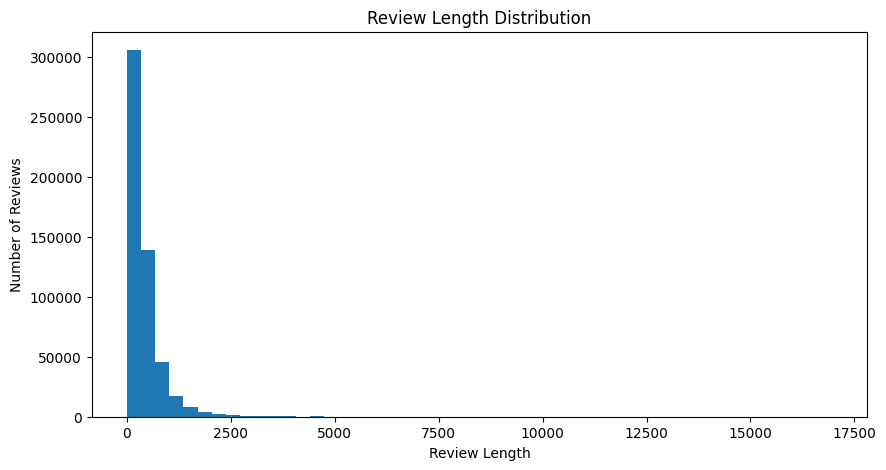

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df_model['review_length'],
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")

plt.show()

In [15]:
df_model.sort_values(
    by='review_length',
    ascending=False
)[['review_length','Text']].head()

,review_length,Text
68700,16952,**********************************************...
346183,13065,Tea Antioxidants<br />----------------<br /><b...
175972,12518,PROS:<br />Very nearly like sugar<br />Works g...
331318,12331,"A few reviewers commented in a black & white, ..."
541158,11861,"I must admit, I haven't gotten many gift baske..."


In [16]:
df_model.groupby('Sentiment')['review_length'].describe()

,count,mean,std,min,25%,50%,75%,max
Sentiment,,,,,,,,
0,82037.0,482.644636,498.685722,12.0,205.0,345.0,578.0,11861.0
1,443777.0,419.559896,426.534718,18.0,173.0,288.0,505.0,16952.0


In [17]:
from collections import Counter
import re

all_text = " ".join(df_model['Text'].astype(str))

words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())

word_counts = Counter(words)

word_counts.most_common(20)

[('the', 1685567),
 ('i', 1536259),
 ('and', 1194769),
 ('a', 1124717),
 ('it', 971092),
 ('to', 924372),
 ('of', 725538),
 ('is', 671213),
 ('this', 619445),
 ('br', 579839),
 ('for', 505621),
 ('in', 501471),
 ('my', 428777),
 ('that', 407072),
 ('you', 337972),
 ('but', 327684),
 ('with', 323487),
 ('have', 318139),
 ('are', 293386),
 ('not', 292593)]

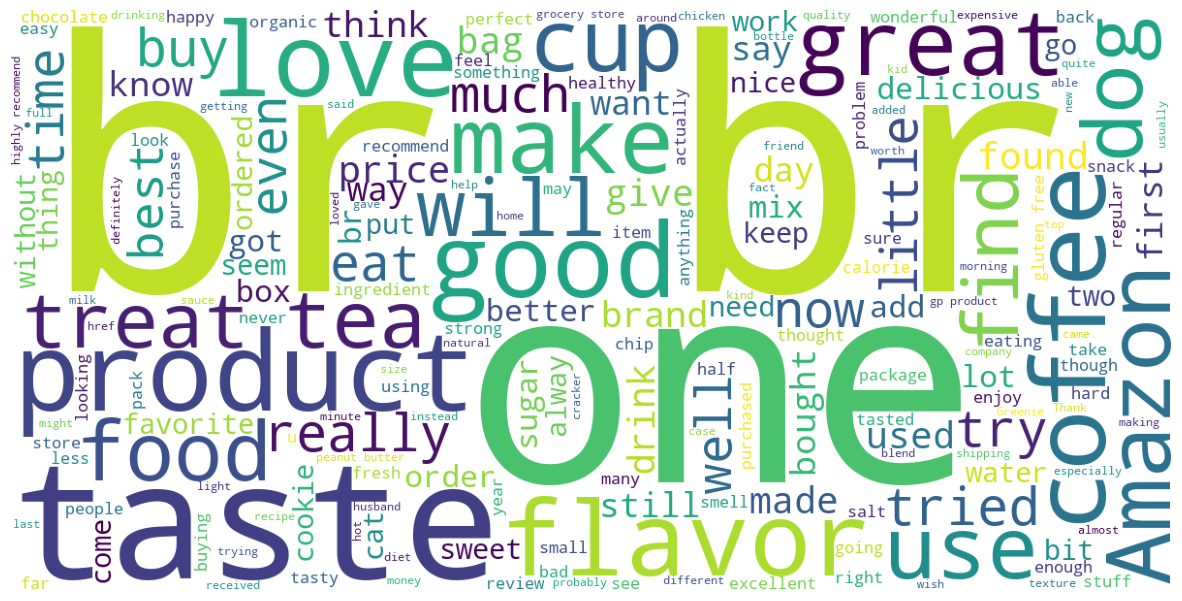

In [18]:
sample_text = " ".join(
    df_model['Text'].head(20000).astype(str)
)


from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(sample_text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [19]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\GAURAV\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\GAURAV\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\GAURAV\AppData\Roaming\nltk_data...


True

In [20]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove non-letters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [21]:
sample_review = df_model['Text'].iloc[0]

print("ORIGINAL REVIEW:")
print(sample_review)

print("\nCLEANED REVIEW:")
print(clean_text(sample_review))

ORIGINAL REVIEW:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

CLEANED REVIEW:
bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better


In [22]:
df_small = df_model.sample(
    n=50000,
    random_state=42
)

print(df_small.shape)

(50000, 3)


In [23]:
df_small['clean_text'] = df_small['Text'].apply(clean_text)

df_small[['Text', 'clean_text']].head()

,Text,clean_text
443593,This is a very high quality dog food with meat...,high quality dog food meat fruit grain dog lov...
136949,I love this cake mix and the other 3 mixes as ...,love cake mix mix well incredible amazon offer...
520459,A nice strong brew. I am new to Keurig and hav...,nice strong brew new keurig lived french press...
219515,I just found PB2 and PB2 with chocolate and I ...,found pb pb chocolate thrilled love sugary goo...
471273,Delightful mint tea as one would expect. Note ...,delightful mint tea one would expect note tea ...


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000
)

X = tfidf.fit_transform(df_small['clean_text'])

y = df_small['Sentiment']

print(X.shape)

(50000, 10000)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(40000, 10000)
(10000, 10000)


Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [27]:
y_pred = lr_model.predict(X_test)

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9124
Precision: 0.9178006416639009
Recall   : 0.9842211412979001
F1 Score : 0.9498511564002748

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.53      0.65      1571
           1       0.92      0.98      0.95      8429

    accuracy                           0.91     10000
   macro avg       0.89      0.76      0.80     10000
weighted avg       0.91      0.91      0.90     10000



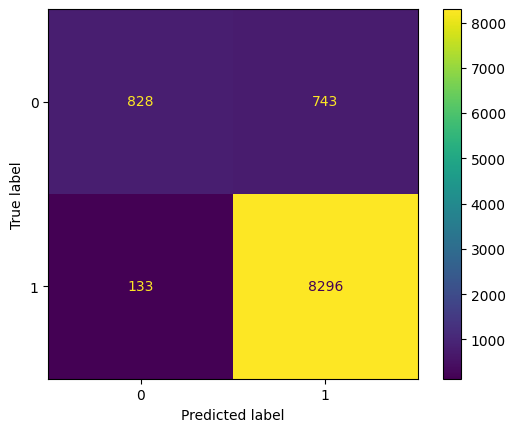

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [30]:
import os

os.makedirs("../models", exist_ok=True)

In [31]:
import joblib

joblib.dump(lr_model, "../models/logistic_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

Naive Bayes

In [32]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.8667


Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.89


XGBoost

In [42]:
import sys
print(sys.executable)

c:\Users\GAURAV\anaconda3\envs\signlang2\python.exe


In [43]:
import sys

!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [44]:
import xgboost
print(xgboost.__version__)

3.2.0


In [45]:
import xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.896


LSTM Model

In [46]:
X_text = df_small['clean_text']
y = df_small['Sentiment']

In [47]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
import tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 20000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

In [49]:
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

In [50]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

print(X_train_pad.shape)
print(X_test_pad.shape)

(40000, 200)
(10000, 200)


In [53]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Input(shape=(max_len,)),
    
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,699,905 (10.30 MB)

 Trainable params: 2,699,905 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [55]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [56]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - accuracy: 0.8405 - loss: 0.4446 - val_accuracy: 0.8435 - val_loss: 0.4361
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2404s 10s/step - accuracy: 0.8435 - loss: 0.4380 - val_accuracy: 0.8435 - val_loss: 0.4345
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - accuracy: 0.8446 - loss: 0.4364 - val_accuracy: 0.8434 - val_loss: 0.4343
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 304s 1s/step - accuracy: 0.8448 - loss: 0.4351 - val_accuracy: 0.8431 - val_loss: 0.4350
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 771s 3s/step - accuracy: 0.8449 - loss: 0.4345 - val_accuracy: 0.8432 - val_loss: 0.4342


In [57]:
test_loss, test_acc = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8434 - loss: 0.4337
Test Accuracy: 0.8434000015258789


In [58]:
model.save("../models/lstm_sentiment.keras")

In [60]:
import pickle

# TF-IDF vectorizer
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

# Logistic Regression model
joblib.dump(lr_model, "../models/logistic_model.pkl")

# LSTM model
model.save("../models/lstm_sentiment.keras")

# Tokenizer
with open("../models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [61]:
results = {
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "XGBoost",
        "LSTM"
    ],
    "Accuracy": [
        0.9124,
        0.8667,
        0.8900,
        0.8960,
        test_acc
    ]
}

import pandas as pd

results_df = pd.DataFrame(results)
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.9124
3,XGBoost,0.8960
2,Random Forest,0.8900
1,Naive Bayes,0.8667
4,LSTM,0.8434
